In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

In [8]:
#  ----------- Data Set URL ------------------
# https://www.kaggle.com/datasets/zhonglifr/thyroid-disease-unsupervised-anomaly-detection

df = pd.read_csv("/content/drive/MyDrive/Machine Learning Tutorial/Machine Learning/Unsupervised Learning/Anomaly Detection/thyroid_dataset.csv")

In [9]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [10]:
df.shape

(6916, 22)

In [11]:
df.columns

Index(['Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3_measured',
       'TT4_measured', 'T4U_measured', 'FTI_measured', 'Outlier_label'],
      dtype='object')

In [12]:
X = df.drop('Outlier_label',axis=1)

y= df['Outlier_label']

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [19]:
from sklearn.neighbors import LocalOutlierFactor

In [25]:
neighbor = LocalOutlierFactor(contamination=0.036)

labels = neighbor.fit_predict(X_scaled)

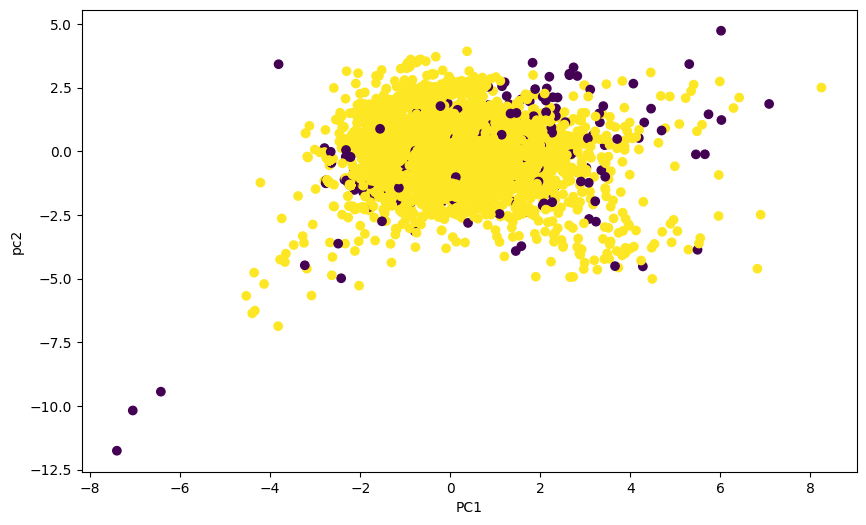

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("pc2")
plt.show()

In [27]:
no_outlier = np.sum(labels == -1)
no_normal = np.sum(labels == 1)

print("Number of Outliers: ",no_outlier)
print("Number of Normal: ",no_normal)

Number of Outliers:  249
Number of Normal:  6667
